/tmp/ipykernel_1768796/235185220.py:703: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(w_pad=4.0)


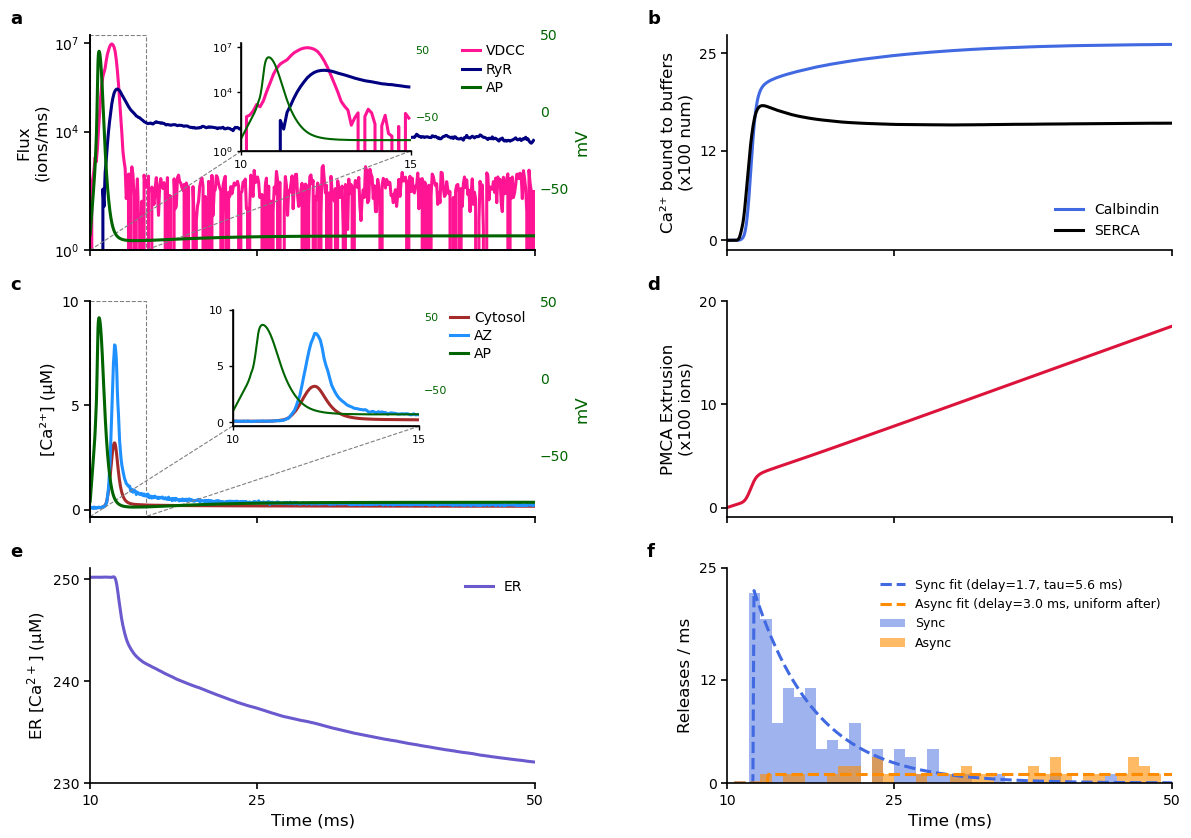

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import NullLocator
from mpl_toolkits.axes_grid1.inset_locator import mark_inset
from scipy.optimize import minimize

from plot_config import apply_style, strip_spines, label_panel, set_n_ticks, save_figure

apply_style()

# ============================================================
#                     USER SETTINGS
# ============================================================

# ---------------- Directory ----------------
dir_control = 'RSV80C250uM_nish2sur_nishRyR_single_pulse'

base_path = "/data/hdrive/phd/results/single_pulse/"
ap_path   = "/data/hdrive/Downloads/VDCC potential/AP.dat"

# ---------------- Figure Layout ----------------
FIGSIZE = (12, 8.5)     
NROWS = 3
NCOLS = 2

XMIN, XMAX = 10, 50

# ---------------- Inset Layout ----------------

INSET_RECT = (0.34, 0.46, 0.38, 0.50)
INSET_RECT_C = (0.32, 0.42, 0.42, 0.54)
INSET_WINDOW = (10, 15)

# ---------------- Save Settings ----------------
SAVE_FIGURE = True
SAVE_NAME   = "fig3_single_AP"
SAVE_FORMAT = "png"     # png, pdf, svg, eps, tif
TRANSPARENT = True

# ---------------- Local Style ----------------

LABEL_FONTSIZE  = 12
TICK_FONTSIZE   = 10
LEGEND_FONTSIZE = 10
LINEWIDTH       = 2.2

# ============================================================
#                      COLOR SETTINGS
# ============================================================

COLORS = {

    # Panel A
    "vdcc"      : "deeppink",
    "ryr_flux"  : "navy",
    "potential1": "darkgreen",

    # Panel B
    "calbindin" : "royalblue",
    "serca_buf" : "black",

    # Panel C
    "cyto_ca"   : "brown",
    "az_ca"     : "dodgerblue",
    "potential2": "darkgreen",

    # Panel D
    "pmca"      : "crimson",

    # Panel E
    "ryr_ctrl"  : "slateblue",

    # Panel F
    "sync"      : "royalblue",
    "async"     : "darkorange"
}

# ============================================================
#                     HELPER FUNCTIONS
# ============================================================

def add_stim_zoom_inset(ax, traces, window, rect, ap_t, ap_v, *,
                         ylim=None, yscale=None, yticks=None,
                         ap_ylim=(-100, 60), ap_yticks=(-50, 50)):
    """Zoomed inset over `window`, styled like plot_config.add_zoom_inset
    (outward ticks, stripped spines, dashed mark_inset connector back to the
    source region on `ax`), plus an AP-potential twin axis -- every full
    panel here carries one, which the shared plot_config helper doesn't
    natively support since RyR_expression_levels.ipynb has no twin axes.
    Unlike add_zoom_inset, y-tick VALUES are shown (no axis label, just the
    numbers) so the inset's own scale is readable at a glance.

    traces: list of (x, y, color) tuples for the main-axis lines.
    """
    inset = ax.inset_axes(rect)
    for x, y, color in traces:
        m = (x >= window[0]) & (x <= window[1])
        inset.plot(x[m], y[m], color=color, lw=LINEWIDTH)

    inset.set_xlim(*window)
    if yscale:
        inset.set_yscale(yscale)
    if ylim is not None:
        inset.set_ylim(*ylim)
    if yticks is not None:
        inset.set_yticks(yticks)
        inset.yaxis.set_minor_locator(NullLocator())
    set_n_ticks(inset, *window, n=2, axis="x")
    inset.tick_params(length=3, width=1.0, direction="out", labelsize=8)
    strip_spines(inset, linewidth=1.0)

    inset_ap = inset.twinx()
    m = (ap_t >= window[0]) & (ap_t <= window[1])
    inset_ap.plot(ap_t[m], ap_v[m], color=COLORS["potential1"], lw=1.5)
    inset_ap.set_ylim(*ap_ylim)
    inset_ap.set_yticks(list(ap_yticks))
    inset_ap.tick_params(axis='y', colors=COLORS["potential1"], length=0, labelsize=8)
    strip_spines(inset_ap)

    mark_inset(ax, inset, loc1=3, loc2=4, fc="none", ec="0.5", lw=0.8, ls="--", zorder=1)
    return inset, inset_ap


# ============================================================
#                     CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(
    NROWS,
    NCOLS,
    figsize=FIGSIZE,
    sharex='col'
)

axes = axes.flatten()

# Hide x tick labels except bottom row
for ax in axes[0:4]:

    ax.tick_params(labelbottom=False)

# ============================================================
#                     PANEL A
#          VDCC / RyR Flux + AP
# ============================================================

ax = axes[0]

data1 = f"{base_path}/{dir_control}/vdccCaFluxRate.dat"
data2 = f"{base_path}/{dir_control}/ryrCaFluxRate.dat"

vdcc_t = np.genfromtxt(data1, usecols=0)
vdcc_f = np.genfromtxt(data1, usecols=1)

ryr_t = np.genfromtxt(data2, usecols=0)
ryr_f = np.genfromtxt(data2, usecols=1)

ap_t = np.genfromtxt(ap_path, usecols=0)
ap_v = np.genfromtxt(ap_path, usecols=1)

ax2 = ax.twinx()

ax2.tick_params(
    axis='y',
    colors=COLORS["potential1"],
    labelcolor=COLORS["potential1"],
    length=0      # No tick marks
)

ax.plot(
    vdcc_t*1000,
    vdcc_f,
    color=COLORS["vdcc"],
    lw=LINEWIDTH,
    label='VDCC'
)

ax.plot(
    ryr_t*1000,
    ryr_f,
    color=COLORS["ryr_flux"],
    lw=LINEWIDTH,
    label='RyR'
)

ax2.plot(
    ap_t*1000,
    ap_v,
    color=COLORS["potential1"],
    lw=LINEWIDTH,
    label='AP'
)

# Twin axis (AP)
ax2.set_yticks([-50, 0, 50])

ax.set_yscale('log')
ax.set_yticks([1, 10000, 10000000])
ax.yaxis.set_minor_locator(NullLocator())

ax.set_ylabel(
    'Flux\n(ions/ms)',
    fontsize=LABEL_FONTSIZE
)

ax2.set_ylabel(
    'mV',
    fontsize=LABEL_FONTSIZE,
    color=COLORS["potential1"]
)

strip_spines(ax)
strip_spines(ax2)

lns1, lbl1 = ax.get_legend_handles_labels()
lns2, lbl2 = ax2.get_legend_handles_labels()

ax.legend(
    lns1 + lns2,
    lbl1 + lbl2,
    fontsize=LEGEND_FONTSIZE,
    frameon=False,
    loc="upper right",
    handlelength=1.3,
    handletextpad=0.4,
    labelspacing=0.3,
    borderaxespad=0.3
)

label_panel(ax, 'a')

# ==========================================================
# Inset for Panel A -- zoom 10-15 ms
# ==========================================================

add_stim_zoom_inset(
    ax,
    [(vdcc_t*1000, vdcc_f, COLORS["vdcc"]), (ryr_t*1000, ryr_f, COLORS["ryr_flux"])],
    INSET_WINDOW, INSET_RECT, ap_t*1000, ap_v,
    yscale='log', yticks=[1e0, 1e4, 1e7],
)

# ============================================================
#                     PANEL B
#          Calbindin + SERCA Buffering
# ============================================================

ax = axes[1]

# ---------- Calbindin ----------

calb_file = f"{base_path}/{dir_control}/calB.dat"

time_calb = np.genfromtxt(calb_file, usecols=0)

calb_bound = np.genfromtxt(
    calb_file,
    usecols=(2,3,4,5,6,7,8,9)
)

total_bound_calb = np.sum(calb_bound, axis=1) / 100.0

# AP arrives at 10 ms
ap_time_ms = 10
idx0 = np.argmin(np.abs(time_calb * 1000 - ap_time_ms))
total_bound_calb = total_bound_calb - total_bound_calb[idx0]
total_bound_calb[time_calb * 1000 < ap_time_ms] = 0

# ---------- SERCA ----------

serca_file = f"{base_path}/{dir_control}/sercaMol.dat"

time_serca = np.genfromtxt(
    serca_file,
    usecols=0
)

x1 = np.genfromtxt(serca_file, usecols=2)
x2 = np.genfromtxt(serca_file, usecols=3)
y2 = np.genfromtxt(serca_file, usecols=4)
y1 = np.genfromtxt(serca_file, usecols=5)

serca_bound = (
    x1 +
    x2*2 +
    y2*2 +
    y1
) / 100.0

idx0 = np.argmin(np.abs(time_serca * 1000 - ap_time_ms))
serca_bound = serca_bound - serca_bound[idx0]
serca_bound[time_serca * 1000 < ap_time_ms] = 0

# ---------- Plot ----------

ax.plot(
    time_calb*1000,
    total_bound_calb,
    color=COLORS["calbindin"],
    lw=LINEWIDTH,
    label='Calbindin'
)

ax.plot(
    time_serca*1000,
    serca_bound,
    color=COLORS["serca_buf"],
    lw=LINEWIDTH,
    label='SERCA'
)

ax.set_ylabel(
    'Ca²⁺ bound to buffers\n(x100 num)',
    fontsize=LABEL_FONTSIZE
)

ax.legend(fontsize=LEGEND_FONTSIZE, frameon=False)
ax.set_yticks([0, 12, 25])

strip_spines(ax)

label_panel(ax, 'b')

# ============================================================
#                     PANEL C
#           Cytosolic + AZ Calcium
# ============================================================

ax = axes[2]

data1 = f"{base_path}/{dir_control}/er_ca_conc.dat"
data2 = f"{base_path}/{dir_control}/pre_ca_conc.dat"
data3 = f"{base_path}/{dir_control}/CaConc"

t1 = np.genfromtxt(data1, usecols=0)
cyto = np.genfromtxt(data2, usecols=1)

az_t = np.genfromtxt(data3, usecols=0)
az_ca = np.genfromtxt(data3, usecols=1)

ax2 = ax.twinx()

ax2.tick_params(
    axis='y',
    colors=COLORS["potential1"],
    labelcolor=COLORS["potential1"],
    length=0      # No tick marks
)

ax.plot(
    t1*1000,
    cyto/1000,
    color=COLORS["cyto_ca"],
    lw=LINEWIDTH,
    label='Cytosol'
)

ax.plot(
    az_t*1000,
    az_ca/1000,
    color=COLORS["az_ca"],
    lw=LINEWIDTH,
    label='AZ'
)

ax2.plot(
    ap_t*1000,
    ap_v,
    color=COLORS["potential2"],
    lw=LINEWIDTH,
    label='AP'
)

ax.set_ylabel(
    '[Ca²⁺] (µM)',
    fontsize=LABEL_FONTSIZE
)

ax2.set_ylabel(
    'mV',
    fontsize=LABEL_FONTSIZE,
    color=COLORS["potential1"]
)

ax2.set_yticks([-50, 0, 50])
ax.set_yticks([0, 5, 10])

strip_spines(ax)
strip_spines(ax2)

lns1, lbl1 = ax.get_legend_handles_labels()
lns2, lbl2 = ax2.get_legend_handles_labels()

ax.legend(
    lns1 + lns2,
    lbl1 + lbl2,
    fontsize=LEGEND_FONTSIZE,
    frameon=False,
    loc="upper right",
    handlelength=1.3,
    handletextpad=0.4,
    labelspacing=0.3,
    borderaxespad=0.3
)

label_panel(ax, 'c')

# ==========================================================
# Inset for Panel C -- zoom 10-15 ms (bigger than panel a's; see
# INSET_RECT_C in USER SETTINGS)
# ==========================================================

add_stim_zoom_inset(
    ax,
    [(t1*1000, cyto/1000, COLORS["cyto_ca"]), (az_t*1000, az_ca/1000, COLORS["az_ca"])],
    INSET_WINDOW, INSET_RECT_C, ap_t*1000, ap_v,
    ylim=ax.get_ylim(),  # share the parent's y-limits, like plot_config.add_zoom_inset
    yticks=[0, 5, 10],   # matches the parent panel's own ticks
)

# ============================================================
#                     PANEL D
#                 PMCA Extrusion
# ============================================================

ax = axes[3]

pmca_file = f"{base_path}/{dir_control}/pmca_leak.dat"

time_pmca = np.genfromtxt(pmca_file, usecols=0)

flux = np.genfromtxt(pmca_file, usecols=1)
leak = np.genfromtxt(pmca_file, usecols=2)

# PMCA extrusion
net_pmca = (flux + leak) / 100

# AP arrives at 10 ms
ap_time_ms = 10
idx0 = np.argmin(np.abs(time_pmca * 1000 - ap_time_ms))

# Shift so that PMCA starts from zero at the AP
net_pmca = net_pmca - net_pmca[idx0]

# Force pre-AP values to zero
net_pmca[time_pmca * 1000 < ap_time_ms] = 0

ax.plot(
    time_pmca*1000,
    net_pmca,
    color=COLORS["pmca"],
    lw=LINEWIDTH
)

ax.set_ylabel(
    'PMCA Extrusion\n(x100 ions)',
    fontsize=LABEL_FONTSIZE
)

ax.set_yticks([0, 10, 20])

strip_spines(ax)

label_panel(ax, 'd')

# ============================================================
#                     PANEL E
#                 ER Calcium Concentration
# ============================================================

ax = axes[4]

er_file = f"{base_path}/{dir_control}/er_ca_conc.dat"

er_time = np.genfromtxt(er_file, usecols=0)
er_ca   = np.genfromtxt(er_file, usecols=1)

ax.plot(
    er_time * 1000,
    er_ca,
    color=COLORS["ryr_ctrl"],
    lw=LINEWIDTH,
    label='ER'
)

ax.set_ylabel(
    'ER [Ca$^{2+}$] (µM)',
    fontsize=LABEL_FONTSIZE
)

ax.legend(fontsize=LEGEND_FONTSIZE, frameon=False)

ax.set_yticks([230, 240, 250])

strip_spines(ax)

label_panel(ax, 'e')

# ============================================================
#                     PANEL F
#                 Vesicle Release
# ============================================================

ax = axes[5]

sync_file  = f"{base_path}/{dir_control}/syncRel"
async_file = f"{base_path}/{dir_control}/asyncRel"

ryr_file   = f"{base_path}/{dir_control}/ryrMol.dat"

# ---------- Load data ----------

sync = np.genfromtxt(sync_file, usecols=0)
sync = sync[~np.isnan(sync)]

a_sync = np.genfromtxt(async_file, usecols=0)
a_sync = a_sync[~np.isnan(a_sync)]

time = np.genfromtxt(ryr_file, usecols=0)

# ---------- Release arrays ----------

release_arr_sync = np.zeros(len(time), dtype=int)
release_arr_async = np.zeros(len(time), dtype=int)

dt = 1e-05

for t in sync:

    idx = int(t / dt)

    if 0 <= idx < len(release_arr_sync):
        release_arr_sync[idx] = 1

for t in a_sync:

    idx = int(t / dt)

    if 0 <= idx < len(release_arr_async):
        release_arr_async[idx] = 1

# ---------- Histogram ----------

bin_size = 0.001

time_bins = np.arange(
    time.min(),
    time.max(),
    bin_size
)

sync_hist, _ = np.histogram(
    time,
    bins=time_bins,
    weights=release_arr_sync
)

async_hist, _ = np.histogram(
    time,
    bins=time_bins,
    weights=release_arr_async
)

# ---------- Convert to ms ----------

time_bin_centers_ms = (
    (time_bins[:-1] + time_bins[1:]) / 2
) * 1000

bar_width_ms = bin_size * 1000

# Only display releases from 12 ms onwards
plot_mask = time_bin_centers_ms >= 12

# ---------- Smooth model overlay (delayed MLE fits) ----------
# Release-rate models fit directly to the individual event times (not the
# binned histogram) by maximum likelihood, truncated to the actual
# recording window. Both populations get a delay parameter (neither can
# start releasing instantaneously); on top of that, synchronous release
# gets a decaying-rate (exponential) term while asynchronous release does
# not, because for this dataset a constant rate after the delay already
# explains the async events at least as well as any decaying-rate model
# does (see the companion timescale-analysis notebook for the full
# AIC-based model comparison that this choice is based on).

ap_dv = np.gradient(ap_v, ap_t)
t_stim_f = ap_t[np.argmax(ap_dv)]
T_window_f = time.max() - t_stim_f

ts_sync_f = np.sort(sync - t_stim_f)
ts_sync_f = ts_sync_f[ts_sync_f >= 0]
ts_async_f = np.sort(a_sync - t_stim_f)
ts_async_f = ts_async_f[ts_async_f >= 0]

def _negloglik_delayed_trunc_exp(params, data, T):
    d, log_tau = params
    tau = np.exp(log_tau)
    if d < 0 or d >= data.min():
        return 1e18
    shifted, Trem = data - d, T - d
    if Trem <= 0:
        return 1e18
    n = len(data)
    return -(-np.sum(shifted)/tau - n*np.log(tau) - n*np.log(1 - np.exp(-Trem/tau)))

def _fit_delayed_trunc_exp_mle(data, T, n_grid=40):
    d_grid = np.linspace(0, data.min()*0.999, n_grid)
    logtau_grid = np.linspace(np.log(3e-4), np.log(3.0), n_grid)
    best = None
    for d in d_grid:
        for lt in logtau_grid:
            val = _negloglik_delayed_trunc_exp([d, lt], data, T)
            if best is None or val < best[0]:
                best = (val, d, lt)
    res = minimize(_negloglik_delayed_trunc_exp, x0=[best[1], best[2]], args=(data, T),
                    method='Nelder-Mead', options={'xatol': 1e-10, 'fatol': 1e-10, 'maxiter': 20000})
    d_opt, logtau_opt = res.x
    return d_opt, np.exp(logtau_opt)

d_sync, tau_sync = _fit_delayed_trunc_exp_mle(ts_sync_f, T_window_f)
d_async = ts_async_f.min()  # MLE for a delayed-uniform model's left edge

tt_fit = np.linspace(0, T_window_f, 400)
sync_rate_curve = np.where(
    tt_fit < d_sync, 0.0,
    len(ts_sync_f) * bin_size * np.exp(-(tt_fit - d_sync)/tau_sync)
    / (tau_sync * (1 - np.exp(-(T_window_f - d_sync)/tau_sync)))
)
async_rate_curve = np.where(
    tt_fit < d_async, 0.0,
    len(ts_async_f) * bin_size / (T_window_f - d_async)
)

# ---------- Plot ----------

ax.bar(
    time_bin_centers_ms[plot_mask],
    sync_hist[plot_mask],
    width=bar_width_ms,
    color=COLORS["sync"],
    alpha=0.5,
    label='Sync'
)

ax.bar(
    time_bin_centers_ms[plot_mask],
    async_hist[plot_mask],
    width=bar_width_ms,
    color=COLORS["async"],
    alpha=0.6,
    label='Async'
)

ax.plot(
    (tt_fit + t_stim_f)*1000, sync_rate_curve,
    color=COLORS["sync"], lw=2.2, ls='--',
    label=f'Sync fit (delay={d_sync*1000:.1f}, tau={tau_sync*1000:.1f} ms)'
)

ax.plot(
    (tt_fit + t_stim_f)*1000, async_rate_curve,
    color=COLORS["async"], lw=2.2, ls='--',
    label=f'Async fit (delay={d_async*1000:.1f} ms, uniform after)'
)

ax.set_xlim(10, max(time)*1000)

ax.set_ylabel(
    'Releases / ms',
    fontsize=LABEL_FONTSIZE
)

ax.legend(fontsize=LEGEND_FONTSIZE-1, frameon=False)

ax.set_yticks([0, 12, 25])

strip_spines(ax)

label_panel(ax, 'f')

# ============================================================
#              SHARED COLUMN X LABELS
# ============================================================

axes[4].set_xlabel(
    'Time (ms)',
    fontsize=LABEL_FONTSIZE
)

axes[5].set_xlabel(
    'Time (ms)',
    fontsize=LABEL_FONTSIZE
)

# ============================================================
#                  LAYOUT + SAVE
# ============================================================

for ax in axes:
    ax.set_xlim(XMIN, XMAX)
    ax.set_xticks([10, 25, 50])

plt.tight_layout(w_pad=4.0)

if SAVE_FIGURE:
    save_figure(fig, f"{SAVE_NAME}.{SAVE_FORMAT}", transparent=TRANSPARENT)

plt.show()

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plot_config import strip_spines, label_panel, save_figure

# ============================================================
#   Load rigorous kinetics from the companion analysis notebook
# ============================================================
# Rise/decay time constants are NOT recomputed here -- they're loaded from
# figS1_model_fits_timescales.ipynb's saved output. That
# notebook fits each signal with an appropriate model (sigmoid rise for a
# driven response, adaptive-window exponential/bi-exponential decay,
# chosen and validated by R^2/AIC) and anchors every timing to the AP's
# actual measured upstroke (max dV/dt), rather than the nominal "AP at
# 10 ms" convention used for the panel a-f data windows. Re-run that
# notebook (and it will re-save its CSV) if the underlying simulation
# output ever changes -- this cell only reads the result, so there is
# exactly one place these numbers are computed, not two that can silently
# drift apart. `t_stim_f` (the same max-dV/dt upstroke time, computed live
# from the same AP.dat already loaded in the main figure cell) confirms
# the two notebooks agree on that reference point to 2 decimal places.
_ts = pd.read_csv("figS1_model_fits_timescales_summary.csv")


def _ts_val(signal, metric):
    row = _ts[(_ts["signal"] == signal) & (_ts["metric"] == metric)]
    return float(row["value_ms"].iloc[0]) if len(row) else np.nan


vdcc_kinetics = {
    "time_to_peak_ms": _ts_val("VDCC", "time to peak"),
    "rise_tau_ms": _ts_val("VDCC", "rise tau (sigmoid fit, true onset)"),
    "decay_tau_fast_ms": _ts_val("VDCC", "decay tau (exp fit, adaptive window)"),
}
ryr_kinetics = {
    "time_to_peak_ms": _ts_val("RyR", "time to peak"),
    "rise_tau_ms": _ts_val("RyR", "rise tau (sigmoid fit, true onset)"),
    "decay_tau_fast_ms": _ts_val("RyR", "decay tau (fast, exp fit, adaptive window)"),
    "decay_tau_slow_ms": _ts_val("RyR", "decay tau (slow, exp fit, adaptive window)"),
}

print("=" * 66)
print(f"{'Channel':<10}{'t-to-peak (ms)':>16}{'rise tau (ms)':>16}{'decay fast (ms)':>17}{'decay slow (ms)':>17}")
print("-" * 66)
print(f"{'VDCC':<10}{vdcc_kinetics['time_to_peak_ms']:>16.3f}{vdcc_kinetics['rise_tau_ms']:>16.3f}"
      f"{vdcc_kinetics['decay_tau_fast_ms']:>17.3f}{'n/a':>17}")
print(f"{'RyR':<10}{ryr_kinetics['time_to_peak_ms']:>16.3f}{ryr_kinetics['rise_tau_ms']:>16.3f}"
      f"{ryr_kinetics['decay_tau_fast_ms']:>17.3f}{ryr_kinetics['decay_tau_slow_ms']:>17.3f}")
print("-" * 66)
print(f"All times relative to the AP upstroke (t_stim = {t_stim_f*1000:.2f} ms, max dV/dt).")
print("VDCC's decay is well-described by a single exponential; RyR additionally")
print("shows a slow secondary phase, i.e. a genuine fast+slow bi-exponential")
print("decay -- consistent with RyR/CICR feeding a residual calcium pool rather")
print("than shutting off after the initial transient.")
print("=" * 66)

# ============================================================
#   Summary figure -- same style/colors as the rest of the script

Channel     t-to-peak (ms)   rise tau (ms)  decay fast (ms)  decay slow (ms)
------------------------------------------------------------------
VDCC                 1.310           0.144            0.097              n/a
RyR                  1.810           0.113            0.549           14.958
------------------------------------------------------------------
All times relative to the AP upstroke (t_stim = 10.64 ms, max dV/dt).
VDCC's decay is well-described by a single exponential; RyR additionally
shows a slow secondary phase, i.e. a genuine fast+slow bi-exponential
decay -- consistent with RyR/CICR feeding a residual calcium pool rather
than shutting off after the initial transient.


### Results-summary numbers (manuscript text)

Peak/timing/fold-change numbers cited in the single-AP results paragraph,
grouped by panel. Reuses data already loaded above -- `vdcc_kinetics`/
`ryr_kinetics` from the timescale-summary cell (rigorous rise/decay time
constants, loaded from the companion analysis notebook's saved fits) and
`t_stim_f` (the AP's measured upstroke, computed live in the main figure
cell) for peak-timing and rise/decay taus, plus the raw traces/fit
parameters from the main figure cell (`cyto`, `az_ca`, `total_bound_calb`,
`serca_bound`, `net_pmca`, `er_ca`, `sync`, `a_sync`, `d_sync`, `tau_sync`,
`d_async`) for magnitudes/counts -- rather than reloading anything from
disk. All "post-AP" times below are relative to `t_stim_f`, not the
nominal 10 ms stimulus-window boundary used elsewhere in this notebook for
data selection.

In [3]:
AP_MS = t_stim_f * 1000  # measured AP upstroke, ms -- see cell above

print("=" * 60)
print("Panel a: VDCC / RyR flux")
print("=" * 60)
# Peak *magnitude* uses the raw (unsmoothed) trace -- what's actually
# plotted in the figure. Timing/kinetics (time-to-peak, rise/decay tau)
# come from vdcc_kinetics/ryr_kinetics (the companion notebook's rigorous
# fits), not a local recomputation.
vdcc_peak = vdcc_f.max()
print(f"VDCC peak flux: {vdcc_peak:.2e} ions/ms at t={vdcc_kinetics['time_to_peak_ms']:.2f} ms post-AP")
print(f"  rise tau (sigmoid): {vdcc_kinetics['rise_tau_ms']:.3f} ms; "
      f"decay tau: {vdcc_kinetics['decay_tau_fast_ms']:.3f} ms (single exponential, no slow phase)")
vdcc_post = vdcc_f[vdcc_t * 1000 > 15]
print(f"  post-transient (>15 ms) baseline range: {vdcc_post.min():.0f}-{vdcc_post.max():.0f} ions/ms")

ryr_peak = ryr_f.max()
print(f"RyR peak flux : {ryr_peak:.2e} ions/ms at t={ryr_kinetics['time_to_peak_ms']:.2f} ms post-AP")
print(f"  rise tau (sigmoid): {ryr_kinetics['rise_tau_ms']:.3f} ms; "
      f"decay tau: fast={ryr_kinetics['decay_tau_fast_ms']:.3f} ms, slow={ryr_kinetics['decay_tau_slow_ms']:.2f} ms")
ryr_post = ryr_f[ryr_t * 1000 > 30]
print(f"  sustained plateau (>30 ms): mean={ryr_post.mean():.0f}, range {ryr_post.min():.0f}-{ryr_post.max():.0f} ions/ms")
print(f"VDCC:RyR peak-flux ratio: {vdcc_peak / ryr_peak:.1f}x")
print()

print("=" * 60)
print("Panel c: Cytosolic / AZ calcium")
print("=" * 60)
cyto_uM = cyto / 1000.0
az_uM = az_ca / 1000.0
t_cyto_ms = t1 * 1000.0
t_az_ms = az_t * 1000.0
rest_mask = t_cyto_ms < AP_MS
print(f"Resting cytosolic [Ca2+] (pre-AP): {cyto_uM[rest_mask].mean() * 1000:.1f} nM")
print(f"Cytosolic peak: {cyto_uM.max():.2f} uM at t={t_cyto_ms[np.argmax(cyto_uM)] - AP_MS:.2f} ms post-AP")
print(f"AZ peak      : {az_uM.max():.2f} uM at t={t_az_ms[np.argmax(az_uM)] - AP_MS:.2f} ms post-AP")
print(f"AZ:Cytosol peak ratio: {az_uM.max() / cyto_uM.max():.2f}x")
print(f"Cytosolic level at end of window (t>45ms, mean): {cyto_uM[t_cyto_ms > 45].mean() * 1000:.0f} nM")
print(f"AZ level at end of window (t>45ms, mean)      : {az_uM[t_az_ms > 45].mean() * 1000:.0f} nM")
print("(Note: this is a 50-ms window -- neither trace has fully returned to")
print(" the ~100 nM resting baseline by the end of it, just decayed toward it.)")
print()

print("=" * 60)
print("Panel b: Calbindin / SERCA buffering")
print("=" * 60)
calb_plateau = total_bound_calb[-1] * 100
serca_plateau = serca_bound[-1] * 100
print(f"Calbindin bound at t=50ms: {calb_plateau:.0f} ions "
      f"(onset delay {_ts_val('Calbindin', 'onset delay'):.2f} ms; "
      f"fast tau={_ts_val('Calbindin', 'binding rise tau (fast, biexp fit, from onset)'):.3f} ms, "
      f"slow tau={_ts_val('Calbindin', 'binding rise tau (slow, biexp fit, from onset)'):.2f} ms)")
print(f"SERCA bound at t=50ms    : {serca_plateau:.0f} ions "
      f"(sigmoid rise tau={_ts_val('SERCA', 'binding rise tau (sigmoid fit, from onset to peak)'):.3f} ms)")
print(f"Calbindin:SERCA ratio: {calb_plateau / serca_plateau:.2f}x")
print()

print("=" * 60)
print("Panel d: PMCA extrusion")
print("=" * 60)
pmca_ions = net_pmca * 100
print(f"Cumulative PMCA extrusion at t=50ms: {pmca_ions[-1]:.0f} ions")
print(f"Onset tau (combined onset+linear fit): {_ts_val('PMCA', 'onset tau (combined onset+linear fit)'):.3f} ms")
print(f"Steady-state extrusion rate: {_ts_val('PMCA', 'steady-state rate (units/ms)') * 100:.1f} ions/ms")
print()

print("=" * 60)
print("Panel e: ER calcium")
print("=" * 60)
t_er_ms = er_time * 1000.0
er_at_50 = er_ca[t_er_ms <= 50][-1]
drop = er_ca[0] - er_at_50
print(f"ER [Ca2+]: {er_ca[0]:.0f} -> {er_at_50:.1f} uM over 40 ms ({drop:.1f} uM, {100 * drop / er_ca[0]:.1f}% drop)")
print(f"Depletion tau: fast={_ts_val('ER (depletion)', 'depletion tau (fast, biexp fit)'):.3f} ms, "
      f"slow={_ts_val('ER (depletion)', 'depletion tau (slow, biexp fit)'):.2f} ms "
      f"(bi-exponential fit; single-exponential R2=0.97 vs. bi-exponential R2=0.9997)")
print()

print("=" * 60)
print("Panel f: Vesicle release")
print("=" * 60)
print(f"Synchronous release : {len(sync)} events, delay={d_sync * 1000:.1f} ms, tau={tau_sync * 1000:.1f} ms")
print(f"Asynchronous release: {len(a_sync)} events, delay={d_async * 1000:.1f} ms, ~uniform rate thereafter "
      f"(no statistically resolvable decay: AIC prefers uniform-after-delay over any decaying-rate model)")
print(f"Sync:Async ratio: {len(sync) / len(a_sync):.1f}")

Panel a: VDCC / RyR flux
VDCC peak flux: 9.02e+06 ions/ms at t=1.31 ms post-AP
  rise tau (sigmoid): 0.144 ms; decay tau: 0.097 ms (single exponential, no slow phase)
  post-transient (>15 ms) baseline range: 0-711 ions/ms
RyR peak flux : 2.72e+05 ions/ms at t=1.81 ms post-AP
  rise tau (sigmoid): 0.113 ms; decay tau: fast=0.549 ms, slow=14.96 ms
  sustained plateau (>30 ms): mean=6921, range 4030-10358 ions/ms
VDCC:RyR peak-flux ratio: 33.2x

Panel c: Cytosolic / AZ calcium
Resting cytosolic [Ca2+] (pre-AP): 101.5 nM
Cytosolic peak: 3.20 uM at t=1.57 ms post-AP
AZ peak      : 7.90 uM at t=1.56 ms post-AP
AZ:Cytosol peak ratio: 2.47x
Cytosolic level at end of window (t>45ms, mean): 170 nM
AZ level at end of window (t>45ms, mean)      : 235 nM
(Note: this is a 50-ms window -- neither trace has fully returned to
 the ~100 nM resting baseline by the end of it, just decayed toward it.)

Panel b: Calbindin / SERCA buffering
Calbindin bound at t=50ms: 2617 ions (onset delay 1.00 ms; fast tau